# Modelagem e Avaliação (v4)
## ELO Médio dos Adversários + Filtro de Jogos Mínimos

**Hipótese:** Informar ao modelo a força média dos adversários enfrentados no ciclo permite ajustar as previsões para seleções que jogaram contra times fracos (eliminatórias regionais fáceis) vs. seleções que enfrentaram times fortes.

**Comparação:** v1 (baseline) vs v4 (v1 + ELO médio adversários + filtro ≥15 jogos)

## 1. Imports e Carregamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from xgboost import XGBRegressor
from scipy.stats import wilcoxon

sns.set_theme(style='whitegrid')
np.random.seed(42)

df_v1 = pd.read_csv('../data/processed/features_completo.csv')
df_v4 = pd.read_csv('../data/processed/features_completo_v4.csv')

print(f'v1: {df_v1.shape} | v4: {df_v4.shape}')
print(f'Seleções removidas pelo filtro: {df_v1.shape[0] - df_v4.shape[0]}')

v1: (248, 10) | v4: (248, 12)
Seleções removidas pelo filtro: 0


## 2. Definição das Features e Divisão Treino/Teste

**Atenção:** Para comparação justa, aplicamos o mesmo filtro na v1 — usamos apenas as seleções que também estão na v4.

In [2]:
features_v1 = [
    'media_gols_marcados_ciclo', 'media_gols_sofridos_ciclo',
    'pct_vitorias_ciclo', 'total_jogos_ciclo',
    'media_gols_marcados_ult15', 'media_gols_sofridos_ult15',
    'pct_vitorias_ult15'
]

features_v4 = features_v1 + ['elo_medio_adv_ciclo', 'elo_medio_adv_ult15']

# Filtrar v1 para conter apenas as seleções presentes na v4
chave_v4 = df_v4[['selecao', 'copa_alvo']]
df_v1_filtrado = df_v1.merge(chave_v4, on=['selecao', 'copa_alvo'])

print(f'v1 filtrado: {df_v1_filtrado.shape[0]} amostras')
print(f'v4:          {df_v4.shape[0]} amostras')

def dividir(df, features):
    X_tr = df[df['copa_alvo'] < 2022][features]
    X_te = df[df['copa_alvo'] == 2022][features]
    y_tr = df[df['copa_alvo'] < 2022]['media_gols_copa']
    y_te = df[df['copa_alvo'] == 2022]['media_gols_copa']
    return X_tr, X_te, y_tr, y_te

X_tr1, X_te1, y_tr1, y_te1 = dividir(df_v1_filtrado, features_v1)
X_tr4, X_te4, y_tr4, y_te4 = dividir(df_v4, features_v4)

print(f'\nTreino v1: {X_tr1.shape[0]} | Teste v1: {X_te1.shape[0]}')
print(f'Treino v4: {X_tr4.shape[0]} | Teste v4: {X_te4.shape[0]}')

v1 filtrado: 248 amostras
v4:          248 amostras

Treino v1: 216 | Teste v1: 32
Treino v4: 216 | Teste v4: 32


## 3. Treino e Avaliação

In [3]:
def treinar_avaliar(X_tr, X_te, y_tr, y_te, versao):
    resultados = []
    modelos = {}
    for nome, m in [
        ('Regressão Linear', LinearRegression()),
        ('Random Forest',    RandomForestRegressor(n_estimators=100, random_state=42)),
        ('XGBoost',          XGBRegressor(n_estimators=100, random_state=42))
    ]:
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_te)
        resultados.append({
            'Versão': versao, 'Modelo': nome,
            'MAE':  mean_absolute_error(y_te, y_pred),
            'RMSE': root_mean_squared_error(y_te, y_pred),
            'y_pred': y_pred
        })
        modelos[nome] = m
    return resultados, modelos

res_v1, mod_v1 = treinar_avaliar(X_tr1, X_te1, y_tr1, y_te1, 'v1 (filtrado)')
res_v4, mod_v4 = treinar_avaliar(X_tr4, X_te4, y_tr4, y_te4, 'v4')

df_res = pd.DataFrame(res_v1 + res_v4).drop(columns='y_pred')
print('Comparação v1 vs v4 — Teste (Copa 2022):')
print(df_res.sort_values(['Modelo', 'Versão']).to_string(index=False))

Comparação v1 vs v4 — Teste (Copa 2022):
       Versão           Modelo      MAE     RMSE
v1 (filtrado)    Random Forest 0.451156 0.578860
           v4    Random Forest 0.461028 0.568261
v1 (filtrado) Regressão Linear 0.480034 0.565093
           v4 Regressão Linear 0.456479 0.551036
v1 (filtrado)          XGBoost 0.560300 0.687399
           v4          XGBoost 0.518548 0.621398


## 4. Visualização — MAE v1 vs v4

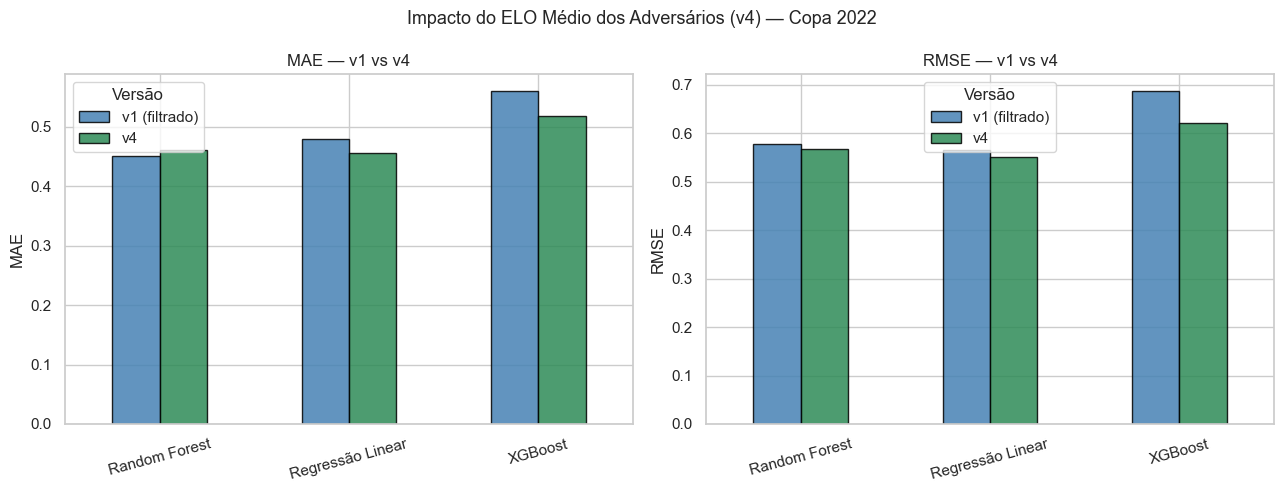

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metrica in zip(axes, ['MAE', 'RMSE']):
    pivot = df_res.pivot(index='Modelo', columns='Versão', values=metrica)
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'seagreen'],
               edgecolor='black', alpha=0.85)
    ax.set_title(f'{metrica} — v1 vs v4')
    ax.set_ylabel(metrica)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Versão')

plt.suptitle('Impacto do ELO Médio dos Adversários (v4) — Copa 2022', fontsize=13)
plt.tight_layout()
plt.savefig('../article/figures/comparacao_v1_v4.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Validação Cruzada Temporal — v1 vs v4

In [5]:
copas_ord = sorted(df_v4['copa_alvo'].unique())
folds = [(copas_ord[:i], copas_ord[i]) for i in range(2, len(copas_ord))]

mae_cv = {'v1_LR': [], 'v1_RF': [], 'v1_XGB': [],
          'v4_LR': [], 'v4_RF': [], 'v4_XGB': []}

for copas_tr, copa_te in folds:
    for df_ver, feats, pref in [
        (df_v1_filtrado, features_v1, 'v1'),
        (df_v4,          features_v4, 'v4')
    ]:
        mask_tr = df_ver['copa_alvo'].isin(copas_tr)
        mask_te = df_ver['copa_alvo'] == copa_te
        Xtr, ytr = df_ver[mask_tr][feats], df_ver[mask_tr]['media_gols_copa']
        Xte, yte = df_ver[mask_te][feats], df_ver[mask_te]['media_gols_copa']

        for suf, m in [
            ('LR',  LinearRegression()),
            ('RF',  RandomForestRegressor(n_estimators=100, random_state=42)),
            ('XGB', XGBRegressor(n_estimators=100, random_state=42))
        ]:
            m.fit(Xtr, ytr)
            mae_cv[f'{pref}_{suf}'].append(mean_absolute_error(yte, m.predict(Xte)))

nomes = {'LR': 'Reg. Linear', 'RF': 'Random Forest', 'XGB': 'XGBoost'}
print('Validação Cruzada Temporal — v1 vs v4:')
print(f'{"Versão/Modelo":<25} {"MAE Médio":>10} {"Std":>10}')
print('-' * 47)
for ver in ['v1', 'v4']:
    for suf in ['LR', 'RF', 'XGB']:
        chave = f'{ver}_{suf}'
        print(f'{ver} — {nomes[suf]:<20} {np.mean(mae_cv[chave]):>10.4f} {np.std(mae_cv[chave]):>10.4f}')

Validação Cruzada Temporal — v1 vs v4:
Versão/Modelo              MAE Médio        Std
-----------------------------------------------
v1 — Reg. Linear              0.4295     0.0395
v1 — Random Forest            0.4450     0.0504
v1 — XGBoost                  0.5275     0.0692
v4 — Reg. Linear              0.4374     0.0464
v4 — Random Forest            0.4515     0.0523
v4 — XGBoost                  0.4923     0.0326


## 6. Teste de Wilcoxon — v1 vs v4

In [6]:
for suf, nome in [('LR', 'Regressão Linear'), ('RF', 'Random Forest'), ('XGB', 'XGBoost')]:
    try:
        stat, p = wilcoxon(mae_cv[f'v1_{suf}'], mae_cv[f'v4_{suf}'])
        v1_mae = np.mean(mae_cv[f'v1_{suf}'])
        v4_mae = np.mean(mae_cv[f'v4_{suf}'])
        melhor = 'v4 ✅' if v4_mae < v1_mae and p < 0.05 else ('v4 (n.s.)' if v4_mae < v1_mae else 'v1')
        print(f'{nome}:')
        print(f'  MAE v1: {v1_mae:.4f} | MAE v4: {v4_mae:.4f} | p={p:.4f} | Melhor: {melhor}')
    except Exception as e:
        print(f'{nome}: {e}')

Regressão Linear:
  MAE v1: 0.4295 | MAE v4: 0.4374 | p=0.5625 | Melhor: v1
Random Forest:
  MAE v1: 0.4450 | MAE v4: 0.4515 | p=0.4375 | Melhor: v1
XGBoost:
  MAE v1: 0.5275 | MAE v4: 0.4923 | p=0.1562 | Melhor: v4 (n.s.)


## 7. Importância de Features — v4

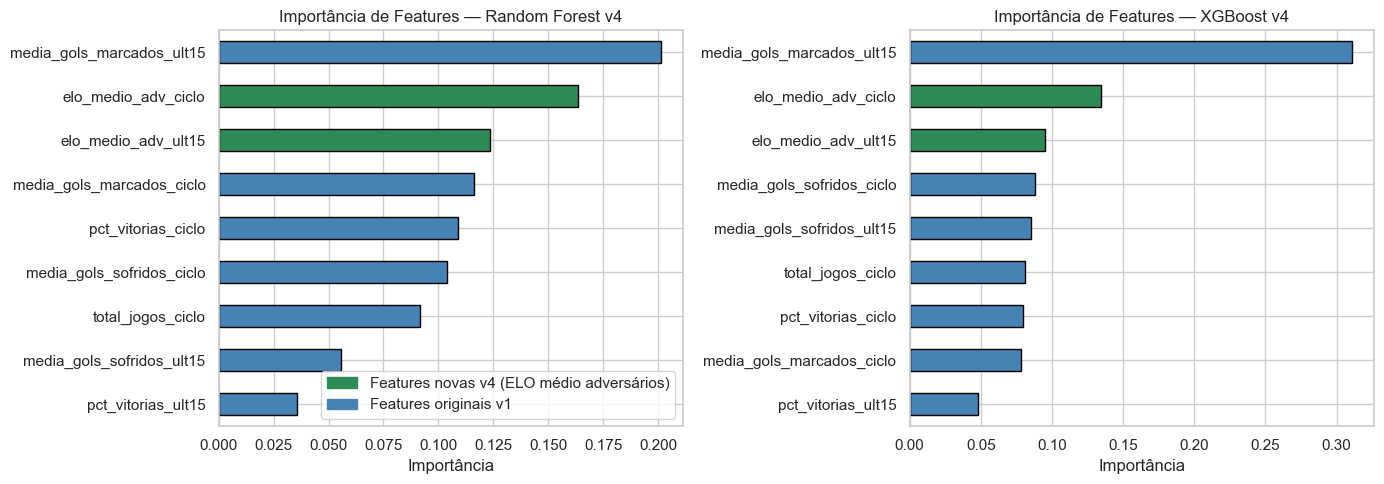

In [7]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (modelo, nome) in zip(axes, [
    (mod_v4['Random Forest'], 'Random Forest v4'),
    (mod_v4['XGBoost'],       'XGBoost v4')
]):
    imp = pd.Series(modelo.feature_importances_, index=features_v4).sort_values()
    colors = ['seagreen' if 'elo_medio' in f else 'steelblue' for f in imp.index]
    imp.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
    ax.set_title(f'Importância de Features — {nome}')
    ax.set_xlabel('Importância')

legend = [
    Patch(color='seagreen',  label='Features novas v4 (ELO médio adversários)'),
    Patch(color='steelblue', label='Features originais v1')
]
axes[0].legend(handles=legend, loc='lower right')

plt.tight_layout()
plt.savefig('../article/figures/importancia_features_v4.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Tabela Final

In [8]:
resumo = pd.DataFrame({
    'Versão':  ['v1 (filtrado)'] * 3 + ['v4'] * 3,
    'Modelo':  ['Reg. Linear', 'Random Forest', 'XGBoost'] * 2,
    'MAE Teste':  [r['MAE']  for r in res_v1 + res_v4],
    'RMSE Teste': [r['RMSE'] for r in res_v1 + res_v4],
    'MAE CV':  [
        np.mean(mae_cv['v1_LR']),  np.mean(mae_cv['v1_RF']),  np.mean(mae_cv['v1_XGB']),
        np.mean(mae_cv['v4_LR']),  np.mean(mae_cv['v4_RF']),  np.mean(mae_cv['v4_XGB']),
    ],
    'Std CV': [
        np.std(mae_cv['v1_LR']),  np.std(mae_cv['v1_RF']),  np.std(mae_cv['v1_XGB']),
        np.std(mae_cv['v4_LR']),  np.std(mae_cv['v4_RF']),  np.std(mae_cv['v4_XGB']),
    ]
}).round(4)

print('Tabela Comparativa Final — v1 vs v4:')
print(resumo.to_string(index=False))

resumo.to_csv('../article/tables/comparacao_v1_v4.csv', index=False)
print('\nTabela salva em article/tables/comparacao_v1_v4.csv')

Tabela Comparativa Final — v1 vs v4:
       Versão        Modelo  MAE Teste  RMSE Teste  MAE CV  Std CV
v1 (filtrado)   Reg. Linear     0.4800      0.5651  0.4295  0.0395
v1 (filtrado) Random Forest     0.4512      0.5789  0.4450  0.0504
v1 (filtrado)       XGBoost     0.5603      0.6874  0.5275  0.0692
           v4   Reg. Linear     0.4565      0.5510  0.4374  0.0464
           v4 Random Forest     0.4610      0.5683  0.4515  0.0523
           v4       XGBoost     0.5185      0.6214  0.4923  0.0326

Tabela salva em article/tables/comparacao_v1_v4.csv


## 9. Conclusão e Seleção do Modelo Final

**Critério de decisão:**
- Se v4 MAE CV < v1 MAE CV **e** Wilcoxon p < 0.05 → **v4 é o modelo final**
- Se diferença não significativa → **v1 pelo princípio da parcimônia**
- Se v4 piorou → **v1 definitivamente**

O modelo selecionado aqui é usado no `04_previsao_2026.ipynb`.

**Próximo passo:** Atualizar `04_previsao_2026.ipynb` com o modelo final e regenerar as previsões.